# 01 — Unified Generator Benchmark

Detailed operational description: [`docs/PROTOCOL.md`, section 2](../../docs/PROTOCOL.md#2-generator-benchmark).

This validation-only notebook answers RQ1. KID/FID use all positive validation references versus the canonical 1,361-image synthetic pool; the PRDC point estimate and repeated 80% stability subsets are balanced. Every sampled ID is recorded. The test split is forbidden. RAW quality defects are retained as warnings and included in RAW metrics; official family ranking uses only strictly quality-valid FILTERED pools.

## 1. Protocol configuration

In [1]:
from pathlib import Path
import datetime as dt
import json
import numpy as np
import os
import sys
BENCHMARK_GPU_UUID = 'GPU-82ec33a5-8b4f-40d0-ead7-8d1d9679055d'  # physical RTX 5060 Ti (16 GiB)
os.environ['CUDA_VISIBLE_DEVICES'] = BENCHMARK_GPU_UUID  # must be set before importing torch/torchvision
ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'configs').is_dir())
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'notebooks/utility'))
from notebooks.utility.generator_benchmark import (
    BENCHMARK_ROOT, CANONICAL_OUTPUTS, FEATURE_SPACES, REPRESENTATIONS, NonFiniteEmbeddingError, atomic_json,
    build_canonical_generator_provenance, build_synthetic_duplication_rows, build_train_memorization_rows, candidate_audit_document_rows,
    build_validation_similarity_rows, deterministic_sample, audit_runtime_generator_assets, diversity_metrics, efficiency_from_manifest,
    canonical_samples_from_manifest, detect_duplicate_generator_identities, eligibility_failures, evaluation_subset_size, extract_features, file_sha256, FrozenLocalFeatureExtractor, get_or_extract_embeddings,
    inception_v3_identity, rad_dino_identity,
    load_protocol, load_registry, metadata_positive_paths, plot_generator_summary,
    paired_kid_differences, rank_generator_family, render_similarity_panel, repeated_distribution_metrics,
    representation_preflight_rows, require_official_family_coverage,
    save_resampling_plan, technical_validity_row, training_corpus_from_manifest, write_csv_rows, balanced_subsample_indices,
)
protocol = load_protocol(ROOT)
registry = load_registry(ROOT)
BUILD_CANONICAL_PROVENANCE = False  # already rebuilt and verified; do not change signed identities during the metric rerun
REFRESH_CANDIDATE_AUDIT = True      # refresh metadata/runtime audit before computing metrics
RUN_REAL_BENCHMARK = True           # final execution: open images, load/cache encoders and recompute outputs
RUN_ID = os.environ.get('MAMMODIFFUSION_BENCHMARK_RUN_ID')
DIVERSITY_PAIR_COUNT = 256
OUTPUT_ROOT = ROOT / BENCHMARK_ROOT
provenance_build_audit = []
if BUILD_CANONICAL_PROVENANCE:
    source_config = json.loads((ROOT / 'configs/generator_provenance_sources.json').read_text())
    shared = {'training_metadata': source_config['training_corpus_evidence'], 'training_dataset_identifier': source_config['training_dataset_identifier'], 'training_corpus_manifest': source_config['shared_training_corpus']['manifest']}
    for source in source_config['generators']:
        try:
            built = build_canonical_generator_provenance(ROOT, {**shared, **source})
            provenance_build_audit.append({'generator_id': source['generator_id'], 'status': 'built', 'lineage': built['lineage_status']})
        except Exception as exc:
            provenance_build_audit.append({'generator_id': source['generator_id'], 'status': 'refused', 'reason': f'{type(exc).__name__}: {exc}'})
{'build_canonical_provenance': BUILD_CANONICAL_PROVENANCE, 'provenance_audit': provenance_build_audit, 'refresh_candidate_audit': REFRESH_CANDIDATE_AUDIT, 'run_real_benchmark': RUN_REAL_BENCHMARK, 'protocol': protocol, 'expected_outputs': CANONICAL_OUTPUTS}

{'build_canonical_provenance': False,
 'provenance_audit': [],
 'refresh_candidate_audit': True,
 'run_real_benchmark': True,
 'protocol': {'schema_version': 2,
  'protocol_version': 2.1,
  'active_amendment': 'configs/generator_benchmark_protocol_amendment_v1.json',
  'amendment_note': 'eligibility_gates below are the ORIGINAL preregistered gates, retained for the historical record; the active selection policy is Option B as defined in active_amendment (perceptual_hash-only rate and rad_dino_coverage are descriptive metrics, not binary gates). Transparent post-benchmark amendment.',
  'pipeline_namespace': 'mammodiffusion.generator_benchmark.v2',
  'study_question': 'RQ1: Which eligible fine-tuned generator and which eligible from-scratch generator provide the best balance of fidelity, diversity, coverage, efficiency, and absence of train memorization?',
  'primary_class': 'positive',
  'synthetic_pool_target': 1361,
  'real_reference_count': 'all_available_validation_positives',
  'e

## 2. Candidate discovery

In [2]:
candidate_audits = detect_duplicate_generator_identities([audit_runtime_generator_assets(ROOT, entry, protocol) for entry in registry['generators'] if entry.get('benchmark', {}).get('enabled', False)])
candidate_audits

[{'generator_id': '01_sd21_baseline_50steps',
  'scientific_family': 'finetuned',
  'model_family': 'sd21_full_finetuning',
  'model_variant': 'baseline_checkpoint_sampling_50',
  'sampling_steps': 50,
  'candidate_role': 'sampling_ablation',
  'eligible_for_downstream_selection': False,
  'representations': {'raw': {'path': 'experiments/diffusers/01_sd21_baseline_50steps/generated_images/final/positive',
    'count': 1411},
   'filtered': {'path': 'experiments/diffusers/01_sd21_baseline_50steps/generated_images/final/positive',
    'count': 1411}},
  'provenance_manifest_exists': True,
  'provenance_manifest_valid': False,
  'lineage_complete': False,
  'raw_manifest_valid': False,
  'filter_manifest_valid': False,
  'sample_set_matches_manifest': False,
  'training_corpus_manifest': 'results/publication_v2/generator_provenance/runtime/shared/rsna_train_real_plus_positive_augmentation.csv',
  'training_corpus_manifest_valid': True,
  'provenance_failure_reason': 'canonical_sample_mani

## 3. Candidate eligibility

In [3]:
eligible = [row for row in candidate_audits if row['eligible_for_benchmark_execution']]
if RUN_REAL_BENCHMARK and not eligible:
    raise RuntimeError('No candidate has complete content-aware provenance, RAW/FILTERED lineage, filter provenance and a declared training corpus.')
[(row['generator_id'], row['candidate_role'], row['eligible_for_downstream_selection'], row['blockers']) for row in candidate_audits]

[('01_sd21_baseline_50steps',
  'sampling_ablation',
  False,
  ['lineage_incomplete', 'provenance_invalid']),
 ('02_sd21_filtered_100steps', 'primary_candidate', True, []),
 ('03_sd21_vae_finetuned', 'primary_candidate', True, []),
 ('04_sd21_lora', 'primary_candidate', True, []),
 ('05_ldm_basic_fromscratch', 'descriptive_baseline', False, []),
 ('06_ldm_extra1361_fromscratch',
  'generation_pool_ablation',
  False,
  ['filter_mapping_hash_mismatch:synth_04082.png->synth_filtered_0032.png',
   'lineage_incomplete',
   'provenance_invalid']),
 ('07_ldm_sdvae_extra1361', 'primary_candidate', True, []),
 ('08_ldm_v3_sdvae_fromscratch', 'primary_candidate', True, [])]

## 4. RAW/FILTERED image counts

In [4]:
counts = [{
    'generator_id': row['generator_id'],
    **{name: row['representations'][name]['count'] for name in REPRESENTATIONS}
} for row in candidate_audits]
counts

[{'generator_id': '01_sd21_baseline_50steps', 'raw': 1411, 'filtered': 1411},
 {'generator_id': '02_sd21_filtered_100steps', 'raw': 2722, 'filtered': 1361},
 {'generator_id': '03_sd21_vae_finetuned', 'raw': 2722, 'filtered': 1361},
 {'generator_id': '04_sd21_lora', 'raw': 2722, 'filtered': 1361},
 {'generator_id': '05_ldm_basic_fromscratch', 'raw': 2722, 'filtered': 1361},
 {'generator_id': '06_ldm_extra1361_fromscratch',
  'raw': 4083,
  'filtered': 1361},
 {'generator_id': '07_ldm_sdvae_extra1361', 'raw': 4083, 'filtered': 1361},
 {'generator_id': '08_ldm_v3_sdvae_fromscratch',
  'raw': 4083,
  'filtered': 1361}]

## 5. Real reference set

In [5]:
validation_paths = validation_ids = None
if RUN_REAL_BENCHMARK:
    required_metadata = [ROOT / 'data/processed/metadata/val.csv']
    missing = [str(path) for path in required_metadata if not path.is_file()]
    if missing:
        raise FileNotFoundError(f'Required benchmark metadata is missing: {missing}')
    validation_paths, validation_ids = metadata_positive_paths(ROOT, 'data/processed/metadata/val.csv')
    real_reference_count = len(validation_paths)
    reference_status = {'real_reference_count': real_reference_count, 'memorization_policy': 'generator-specific declared full training corpus'}
else:
    reference_status = {'status': 'Deferred: no real dataset was opened', 'policy': 'all validation positives; generator-specific declared full training corpus for memorization'}
reference_status

{'real_reference_count': 73,
 'memorization_policy': 'generator-specific declared full training corpus'}

## 6. Technical validity

In [6]:
candidate_audit_rows = candidate_audit_document_rows(candidate_audits)
if REFRESH_CANDIDATE_AUDIT:
    write_csv_rows(OUTPUT_ROOT / 'candidate_audit.csv', candidate_audit_rows)
technical_rows = candidate_preflight = family_preflight_counts = None
if RUN_REAL_BENCHMARK:
    technical_rows = list()
    for audit in candidate_audits:
        if not audit['eligible_for_descriptive_benchmark']:
            continue
        entry = next(item for item in registry['generators'] if item['id'] == audit['generator_id'])
        for representation in REPRESENTATIONS:
            provenance = json.loads((ROOT / entry['provenance_manifest']).read_text())
            paths, _, _ = canonical_samples_from_manifest(ROOT, provenance[f'{representation}_sample_manifest'])
            technical_rows.append(technical_validity_row(audit['generator_id'], representation, paths, minimum_unique=protocol['synthetic_pool_target'], maximum_exact_duplicate_rate=protocol['eligibility_gates']['maximum_exact_duplicate_rate']))
    write_csv_rows(OUTPUT_ROOT / 'technical_validity.csv', technical_rows)
    candidate_preflight = representation_preflight_rows(candidate_audits, technical_rows)
    family_preflight_counts = require_official_family_coverage(candidate_preflight)
{'technical_validity': technical_rows, 'candidate_preflight': candidate_preflight, 'official_filtered_by_family': family_preflight_counts} if technical_rows is not None else 'Deferred until RUN_REAL_BENCHMARK=True'

{'technical_validity': [{'generator_id': '02_sd21_filtered_100steps',
   'condition': 'RAW',
   'n_discovered': 2722,
   'n_readable': 2722,
   'n_corrupt': 0,
   'n_wrong_shape': 0,
   'n_feature_extractable': 2722,
   'n_feature_nonextractable': 0,
   'feature_extractable_rate': 1.0,
   'n_unique_feature_extractable_content': 2722,
   'n_exact_duplicates_among_feature_extractable': 0,
   'n_near_black': 0,
   'n_invalid_range': 0,
   'n_quality_valid': 2722,
   'n_quality_invalid': 0,
   'quality_validity_rate': 1.0,
   'n_unique_quality_valid_content': 2722,
   'n_exact_duplicates_among_quality_valid': 0,
   'n_technically_valid': 2722,
   'n_technically_invalid': 0,
   'n_unique_valid_content': 2722,
   'n_exact_duplicates_among_valid': 0,
   'technical_validity_rate': 1.0,
   'eligible_for_distribution_metrics': True,
   'eligible_for_official_ranking': False,
   'quality_warning': False,
   'warning_reasons': '',
   'fatal_failure_reasons': '',
   'failure_reason': ''},
  {'gener

## 7. Feature extraction

In [7]:
embedding_cache_root = OUTPUT_ROOT / 'embedding_cache'
INCEPTION_CHECKPOINT_PATH = Path('/home/fede/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth')  # verified local torchvision checkpoint
RAD_DINO_SNAPSHOT_PATH = ROOT / 'notebooks/pretrained_model/rad-dino'  # verified complete local microsoft/rad-dino snapshot
ENCODER_IDENTITIES = {}
candidate_features = reference_features = candidate_paths = candidate_ids = None
feature_extraction_failures = cache_events = feature_family_counts = None
if RUN_REAL_BENCHMARK:
    if INCEPTION_CHECKPOINT_PATH is None or RAD_DINO_SNAPSHOT_PATH is None:
        raise RuntimeError('Set both local encoder paths; the benchmark will not download models or use generic weight identifiers.')
    import torch
    import torchvision
    inception_path, rad_path = Path(INCEPTION_CHECKPOINT_PATH), Path(RAD_DINO_SNAPSHOT_PATH)
    LOCAL_ENCODER_PATHS = {'inception_v3': inception_path, 'rad_dino': rad_path}
    _local_encoder_extractors = {}
    def local_feature_extractor(feature_space):  # one frozen model per space, reused across cache misses
        extractor = _local_encoder_extractors.get(feature_space)
        if extractor is None:
            extractor = FrozenLocalFeatureExtractor(feature_space, LOCAL_ENCODER_PATHS[feature_space], device='cuda:0')
            _local_encoder_extractors[feature_space] = extractor
        return extractor
    def extract_local_features(paths, feature_space):
        return local_feature_extractor(feature_space).extract(paths)
    def close_local_encoders():
        while _local_encoder_extractors:
            _, extractor = _local_encoder_extractors.popitem()
            extractor.close()
    ENCODER_IDENTITIES['inception_v3'] = inception_v3_identity(torchvision.__version__, 'Inception_V3_Weights.IMAGENET1K_V1', inception_path, {'resize': 299, 'normalization': 'weights-enum-default'})
    ENCODER_IDENTITIES['rad_dino'] = rad_dino_identity('microsoft/rad-dino', rad_path, commit_hash=rad_path.name if rad_path.parent.name == 'snapshots' else None, config_path=rad_path / 'config.json', weight_paths=sorted(rad_path.glob('*.safetensors')), processor_config_path=rad_path / 'preprocessor_config.json', preprocessing_configuration={'processor': 'local AutoImageProcessor configuration'})
    if not torch.cuda.is_available():
        raise RuntimeError('CUDA is required for the real benchmark')
    gpu_properties = torch.cuda.get_device_properties(0); observed_gpu_uuid = str(gpu_properties.uuid)
    requested_gpu_uuid = os.environ.get('CUDA_VISIBLE_DEVICES', '')
    if requested_gpu_uuid.startswith('GPU-') and observed_gpu_uuid.lower() != requested_gpu_uuid[4:].lower():
        raise RuntimeError(f'Requested GPU UUID {requested_gpu_uuid}, but CUDA local 0 reports {observed_gpu_uuid}')
    extractor_preflight = {}
    preflight_paths = validation_paths[:min(2, len(validation_paths))]
    if not preflight_paths:
        raise RuntimeError('Extractor preflight requires at least one validation image')
    for extractor_name in FEATURE_SPACES:
        torch.cuda.reset_peak_memory_stats(0)
        first = extract_local_features(preflight_paths, extractor_name)
        second = extract_local_features(preflight_paths, extractor_name)
        expected_dimension = 2048 if extractor_name == 'inception_v3' else 768
        if first.shape != (len(preflight_paths), expected_dimension) or not np.isfinite(first).all():
            raise RuntimeError(f'{extractor_name} preflight returned invalid features: {first.shape}')
        if not np.array_equal(first, second):
            raise RuntimeError(f'{extractor_name} preflight is not deterministic')
        extractor_preflight[extractor_name] = {'status': 'pass', 'sample_count': len(preflight_paths), 'feature_shape': list(first.shape), 'finite': True, 'deterministic': True, 'evaluation_mode': True, 'gradients_enabled': False, 'peak_memory_bytes': int(torch.cuda.max_memory_allocated(0))}
        del first, second
        torch.cuda.empty_cache()
    RUN_ID = RUN_ID or f"generator_benchmark_{dt.datetime.now(dt.timezone.utc).strftime('%Y%m%dT%H%M%SZ')}"
    run_root = OUTPUT_ROOT / 'runs' / RUN_ID
    execution_config = {'schema_version': 1, 'run_id': RUN_ID, 'created_at_utc': dt.datetime.now(dt.timezone.utc).isoformat(), 'status': 'running', 'repository_root': str(ROOT), 'working_directory': str(Path.cwd()), 'git_head_informational': os.environ.get('MAMMODIFFUSION_GIT_HEAD'), 'protocol': 'configs/generator_benchmark_protocol.json', 'run_real_benchmark': True, 'build_canonical_provenance': BUILD_CANONICAL_PROVENANCE, 'python_version': sys.version, 'pytorch_version': torch.__version__, 'torchvision_version': torchvision.__version__, 'cuda_build_version': torch.version.cuda, 'gpu': {'cuda_visible_devices': requested_gpu_uuid, 'local_cuda_index': 0, 'name': torch.cuda.get_device_name(0), 'uuid': observed_gpu_uuid, 'total_memory_bytes': int(gpu_properties.total_memory), 'free_memory_bytes_at_start': int(torch.cuda.mem_get_info(0)[0])}, 'extractor_identities': ENCODER_IDENTITIES, 'extractor_preflight': extractor_preflight, 'stability_repetitions': protocol['resampling']['stability_repetitions'], 'resampling_fraction': protocol['resampling']['subsampling_fraction'], 'nearest_neighbour_k': protocol['resampling']['nearest_neighbour_k'], 'practical_equivalence_margin': protocol['selection']['practical_equivalence_margin'], 'candidates_included': [row['generator_id'] for row in candidate_preflight if row['raw_descriptive_ready'] or row['filtered_descriptive_ready']], 'candidates_excluded': [{'generator_id': row['generator_id'], 'reason': row['block_reasons']} for row in candidate_preflight if not (row['raw_descriptive_ready'] or row['filtered_descriptive_ready'])]}
    atomic_json(run_root / 'execution_config.json', execution_config)
    candidate_features, reference_features, candidate_paths, candidate_ids = dict(), dict(), dict(), dict()
    feature_extraction_failures, cache_events = list(), list()
    execution_ids = {row['generator_id'] for row in candidate_audits if row['eligible_for_benchmark_execution']}
    benchmark_keys = {(row['generator_id'], row['condition'].lower()) for row in technical_rows if row['eligible_for_distribution_metrics'] and row['generator_id'] in execution_ids}
    reference_sets = {'validation': (validation_paths, validation_ids, 'data/processed/metadata/val.csv')}
    for pool_name, (paths, ids, manifest) in reference_sets.items():
        for extractor_name in FEATURE_SPACES:
            cache = embedding_cache_root / '_references' / pool_name / f'{extractor_name}.npy'
            reference_features[(pool_name, extractor_name)], cache_metadata = get_or_extract_embeddings(
                cache, paths, ids, extractor=extractor_name, preprocessing='registered frozen extractor preprocessing',
                code_version='embedding-integrity-v3', source_manifest=str(ROOT / manifest), metadata_csv=str(ROOT / manifest),
                extractor_model_id=ENCODER_IDENTITIES[extractor_name].get('model_repository', ENCODER_IDENTITIES[extractor_name].get('weights_enum')), extractor_weights_identifier=ENCODER_IDENTITIES[extractor_name]['identity_sha256'], extractor_identity=ENCODER_IDENTITIES[extractor_name],
                extract_fn=extract_local_features)
            cache_events.append({'scope': 'reference', 'pool': pool_name, 'extractor': extractor_name, 'cache_event': cache_metadata['cache_event'], 'reason': cache_metadata['cache_invalidation_reason']})
    for audit in candidate_audits:
        entry = next(item for item in registry['generators'] if item['id'] == audit['generator_id'])
        for representation in REPRESENTATIONS:
            key = (audit['generator_id'], representation)
            if key not in benchmark_keys:
                continue
            provenance = json.loads((ROOT / entry['provenance_manifest']).read_text())
            discovered_paths, discovered_ids, _ = canonical_samples_from_manifest(ROOT, provenance[f'{representation}_sample_manifest'])
            selected = set(deterministic_sample(discovered_paths, protocol['synthetic_pool_target'], protocol['sampling']['seed']))
            pairs = [(path, sample_id) for path, sample_id in zip(discovered_paths, discovered_ids) if str(path) in selected]
            paths, ids = [item[0] for item in pairs], [item[1] for item in pairs]; candidate_paths[key] = paths; candidate_ids[key] = ids
            for extractor_name in FEATURE_SPACES:
                cache = embedding_cache_root / audit['generator_id'] / representation / f'{extractor_name}.npy'
                try:
                    candidate_features[(audit['generator_id'], representation, extractor_name)], cache_metadata = get_or_extract_embeddings(
                        cache, paths, ids, extractor=extractor_name, preprocessing='registered frozen extractor preprocessing',
                        code_version='embedding-integrity-v3', source_manifest=str(ROOT / entry['provenance_manifest']),
                        extractor_model_id=ENCODER_IDENTITIES[extractor_name].get('model_repository', ENCODER_IDENTITIES[extractor_name].get('weights_enum')), extractor_weights_identifier=ENCODER_IDENTITIES[extractor_name]['identity_sha256'], extractor_identity=ENCODER_IDENTITIES[extractor_name],
                        extract_fn=extract_local_features)
                    cache_events.append({'scope': 'candidate', 'generator_id': audit['generator_id'], 'representation': representation, 'extractor': extractor_name, 'cache_event': cache_metadata['cache_event'], 'reason': cache_metadata['cache_invalidation_reason']})
                except NonFiniteEmbeddingError as exc:
                    feature_extraction_failures.extend({'generator_id': audit['generator_id'], 'representation': representation, **failure} for failure in exc.failures)
                    benchmark_keys.discard(key)
                    for feature_space in FEATURE_SPACES:
                        candidate_features.pop((audit['generator_id'], representation, feature_space), None)
                    break
    feature_preflight = [{**row, 'filtered_official_ranking_ready': row['filtered_official_ranking_ready'] and all((row['generator_id'], 'filtered', extractor) in candidate_features for extractor in FEATURE_SPACES)} for row in candidate_preflight]
    feature_family_counts = require_official_family_coverage(feature_preflight)
feature_status = 'Deferred' if candidate_features is None else {'candidate_feature_sets': len(candidate_features), 'reference_feature_sets': len(reference_features), 'cache_events': cache_events, 'feature_extraction_failures': feature_extraction_failures, 'official_filtered_by_family': feature_family_counts}
feature_status

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

{'candidate_feature_sets': 24,
 'reference_feature_sets': 2,
 'cache_events': [{'scope': 'reference',
   'pool': 'validation',
   'extractor': 'inception_v3',
   'cache_event': 'hit',
   'reason': ''},
  {'scope': 'reference',
   'pool': 'validation',
   'extractor': 'rad_dino',
   'cache_event': 'miss',
   'reason': 'cache_absent_or_metadata_mismatch'},
  {'scope': 'candidate',
   'generator_id': '02_sd21_filtered_100steps',
   'representation': 'raw',
   'extractor': 'inception_v3',
   'cache_event': 'hit',
   'reason': ''},
  {'scope': 'candidate',
   'generator_id': '02_sd21_filtered_100steps',
   'representation': 'raw',
   'extractor': 'rad_dino',
   'cache_event': 'miss',
   'reason': 'cache_absent_or_metadata_mismatch'},
  {'scope': 'candidate',
   'generator_id': '02_sd21_filtered_100steps',
   'representation': 'filtered',
   'extractor': 'inception_v3',
   'cache_event': 'hit',
   'reason': ''},
  {'scope': 'candidate',
   'generator_id': '02_sd21_filtered_100steps',
   'rep

## 8. Distribution metrics

In [8]:
distribution_summaries = distribution_repetitions = None
if RUN_REAL_BENCHMARK:
    distribution_summaries, distribution_repetitions = list(), list()
    stability_size = evaluation_subset_size(protocol['synthetic_pool_target'], len(validation_ids), protocol['synthetic_pool_target'], protocol['resampling']['subsampling_fraction'])
    shared_resampling_plan = balanced_subsample_indices(len(validation_ids), protocol['synthetic_pool_target'], stability_size, protocol['resampling']['stability_repetitions'], protocol['sampling']['seed'], nearest_neighbour_k=protocol['resampling']['nearest_neighbour_k'])
    save_resampling_plan(OUTPUT_ROOT / 'resampling_plan.json', shared_resampling_plan, protocol)
    eligibility = {(row['generator_id'], row['condition'].lower()): row['eligible_for_distribution_metrics'] for row in technical_rows}
    for audit in candidate_audits:
        for representation in REPRESENTATIONS:
            if not eligibility.get((audit['generator_id'], representation), False):  # excluded generators (e.g. G06) are absent from technical_rows
                continue
            for extractor_name in FEATURE_SPACES:
                records, summary = repeated_distribution_metrics(reference_features[('validation', extractor_name)], candidate_features[(audit['generator_id'], representation, extractor_name)], protocol, resampling_plan=shared_resampling_plan)
                distribution_repetitions.extend({'generator_id': audit['generator_id'], 'condition': representation.upper(), 'extractor': extractor_name, **record, 'real_ids': [validation_ids[index] for index in record['real_indices']], 'synthetic_ids': [candidate_ids[(audit['generator_id'], representation)][index] for index in record['synthetic_indices']]} for record in records)
                flat = {**summary['full_pool_distribution_estimates'], **summary['balanced_prdc_point_estimates'], **{f'{metric}_stability_{field}': value for metric, values in summary['stability_estimates'].items() for field, value in values.items()}}
                distribution_summaries.append({'generator_id': audit['generator_id'], 'condition': representation.upper(), 'extractor': extractor_name, **flat, 'full_pool_real_count': summary['full_pool_real_count'], 'full_pool_synthetic_count': summary['full_pool_synthetic_count'], 'balanced_prdc_point_real_count': summary['balanced_prdc_point_real_count'], 'balanced_prdc_point_synthetic_count': summary['balanced_prdc_point_synthetic_count'], 'stability_subset_size': summary['stability_subset_size'], 'stability_interval_type': summary['stability_interval_type'], 'full_pool_distribution_policy': summary['full_pool_distribution_policy'], 'fid_full_pool_caveat': summary['fid_full_pool_caveat']})
    write_csv_rows(OUTPUT_ROOT / 'distribution_metrics_repetitions.csv', distribution_repetitions)
    write_csv_rows(OUTPUT_ROOT / 'distribution_metrics_summary.csv', distribution_summaries)
distribution_summaries if distribution_summaries is not None else {'status': 'Deferred', 'resampling': protocol['resampling']}

[{'generator_id': '02_sd21_filtered_100steps',
  'condition': 'RAW',
  'extractor': 'inception_v3',
  'kid_full_pool': 0.042610213945983855,
  'fid_full_pool': 104.6877848221529,
  'precision_balanced_point': 0.5205479452054794,
  'recall_balanced_point': 0.589041095890411,
  'density_balanced_point': 0.2520547945205479,
  'coverage_balanced_point': 0.4520547945205479,
  'kid_stability_mean': 0.04264020850102407,
  'kid_stability_median': 0.042260505675431714,
  'kid_stability_standard_deviation': 0.00501951030984675,
  'kid_stability_percentile_2_5': 0.03355471765243031,
  'kid_stability_percentile_97_5': 0.05268529520502721,
  'kid_stability_valid_repetitions': 200,
  'precision_stability_mean': 0.4563793103448276,
  'precision_stability_median': 0.46551724137931033,
  'precision_stability_standard_deviation': 0.07304495915936025,
  'precision_stability_percentile_2_5': 0.3103448275862069,
  'precision_stability_percentile_97_5': 0.5866379310344828,
  'precision_stability_valid_repet

## 9. Diversity analysis

In [9]:
diversity_rows = None
if RUN_REAL_BENCHMARK:
    diversity_rows = list()
    for audit in candidate_audits:
        for representation in REPRESENTATIONS:
            key = (audit['generator_id'], representation)
            if key not in benchmark_keys:
                continue
            diversity_rows.append({'generator_id': audit['generator_id'], 'condition': representation.upper(),
                                   **diversity_metrics(candidate_paths[key], candidate_features[(*key, 'rad_dino')], pair_count=DIVERSITY_PAIR_COUNT, seed=protocol['sampling']['seed'])})
    write_csv_rows(OUTPUT_ROOT / 'diversity_metrics.csv', diversity_rows)
diversity_rows if diversity_rows is not None else 'Deferred; mandatory metrics are synthetic NN distance, perceptual-hash duplicate rate and deterministic MS-SSIM diversity. LPIPS is optional.'

[{'generator_id': '02_sd21_filtered_100steps',
  'condition': 'RAW',
  'pair_sampling_seed': 20260714,
  'requested_pairs': 256,
  'evaluated_pairs': 256,
  'mean_ms_ssim': 0.438403142093458,
  'ms_ssim_diversity': 0.561596857906542,
  'synthetic_nearest_neighbour_distance_mean': 4.931121457508374,
  'synthetic_nearest_neighbour_distance_median': 4.861541886004415,
  'n_images': 1361,
  'synthetic_exact_duplicate_rate': 0.0,
  'synthetic_duplicate_rate': 0.03967670830271859,
  'perceptual_hash_duplicate_rate': 0.03967670830271859,
  'lpips_status': 'optional_not_evaluated'},
 {'generator_id': '02_sd21_filtered_100steps',
  'condition': 'FILTERED',
  'pair_sampling_seed': 20260714,
  'requested_pairs': 256,
  'evaluated_pairs': 256,
  'mean_ms_ssim': 0.4525801211825693,
  'ms_ssim_diversity': 0.5474198788174307,
  'synthetic_nearest_neighbour_distance_mean': 4.788487131094157,
  'synthetic_nearest_neighbour_distance_median': 4.720653469461462,
  'n_images': 1361,
  'synthetic_exact_dupl

## 10. Duplicate analysis

In [10]:
synthetic_duplication_rows = None
if RUN_REAL_BENCHMARK:
    synthetic_duplication_rows = list()
    for audit in candidate_audits:
        for representation in REPRESENTATIONS:
            key = (audit['generator_id'], representation)
            if key not in benchmark_keys:
                continue
            path_map = dict(zip(candidate_ids[key], candidate_paths[key]))
            rows = build_synthetic_duplication_rows(candidate_features[(*key, 'rad_dino')], candidate_ids[key], path_map, protocol['memorization']['flag_rule'])
            synthetic_duplication_rows.extend({'generator_id': audit['generator_id'], 'condition': representation.upper(), **row} for row in rows)
    write_csv_rows(OUTPUT_ROOT / 'synthetic_duplication.csv', synthetic_duplication_rows)
synthetic_duplication_rows[:5] if synthetic_duplication_rows is not None else 'Deferred'

[{'generator_id': '02_sd21_filtered_100steps',
  'condition': 'RAW',
  'synthetic_id': '02_sd21_filtered_100steps::raw::experiments/diffusers/02_sd21_filtered_100steps/generated_images/final/positive/eval_pos_0005.png',
  'nearest_synthetic_id': '02_sd21_filtered_100steps::raw::experiments/diffusers/02_sd21_filtered_100steps/generated_images/final/positive/gen_1525.png',
  'embedding_distance': 4.377921048771178,
  'ssim': 0.3898212151543237,
  'phash_distance': 8,
  'duplicate_flag': False},
 {'generator_id': '02_sd21_filtered_100steps',
  'condition': 'RAW',
  'synthetic_id': '02_sd21_filtered_100steps::raw::experiments/diffusers/02_sd21_filtered_100steps/generated_images/final/positive/eval_pos_0008.png',
  'nearest_synthetic_id': '02_sd21_filtered_100steps::raw::experiments/diffusers/02_sd21_filtered_100steps/generated_images/final/positive/eval_pos_0099.png',
  'embedding_distance': 5.190512195335013,
  'ssim': 0.6569883801235998,
  'phash_distance': 32,
  'duplicate_flag': False}

## 11. Train memorization analysis

The reference is the generator-specific complete declared training corpus. It includes every real negative, real positive, and positive augmentation actually seen by that generator; the validation-positive-only reference remains a separate descriptive analysis.

In [11]:
train_memorization_rows = None
if RUN_REAL_BENCHMARK:
    train_memorization_rows = list(); training_corpus_by_generator = dict()
    for audit in candidate_audits:
        entry = next(item for item in registry['generators'] if item['id'] == audit['generator_id'])
        if not audit['eligible_for_benchmark_execution']:
            continue
        training_manifest = audit['training_corpus_manifest']
        train_paths, train_ids, train_labels, train_sources = training_corpus_from_manifest(ROOT, training_manifest)
        train_path_map = dict(zip(train_ids, map(Path, train_paths))); training_corpus_by_generator[audit['generator_id']] = training_manifest
        training_manifest_sha256 = file_sha256(ROOT / training_manifest)
        shared_training_cache = embedding_cache_root / 'shared_training_corpora' / training_manifest_sha256 / 'rad_dino.npy'  # content-addressed; generators sharing a corpus reuse one matrix
        train_features, train_cache_metadata = get_or_extract_embeddings(shared_training_cache, train_paths, train_ids, extractor='rad_dino', preprocessing='local recorded RAD-DINO processor', code_version='embedding-integrity-v4', source_manifest=str(ROOT / training_manifest), metadata_csv=str(ROOT / training_manifest), extractor_model_id=ENCODER_IDENTITIES['rad_dino']['model_repository'], extractor_weights_identifier=ENCODER_IDENTITIES['rad_dino']['identity_sha256'], extractor_identity=ENCODER_IDENTITIES['rad_dino'], extract_fn=extract_local_features)
        cache_events.append({'scope': 'training_corpus', 'generator_id': audit['generator_id'], 'training_manifest_sha256': training_manifest_sha256, 'extractor': 'rad_dino', 'cache_event': train_cache_metadata['cache_event'], 'reason': train_cache_metadata['cache_invalidation_reason']})
        for representation in REPRESENTATIONS:
            key = (audit['generator_id'], representation)
            if key not in benchmark_keys:
                continue
            synthetic_path_map = dict(zip(candidate_ids[key], candidate_paths[key]))
            rows = build_train_memorization_rows(candidate_features[(*key, 'rad_dino')], train_features, candidate_ids[key], train_ids, synthetic_path_map, train_path_map, protocol['memorization']['flag_rule'], train_labels, train_sources)
            train_memorization_rows.extend({'generator_id': audit['generator_id'], 'condition': representation.upper(), **row} for row in rows)
    write_csv_rows(OUTPUT_ROOT / 'train_memorization.csv', train_memorization_rows)
    close_local_encoders()
train_memorization_rows[:5] if train_memorization_rows is not None else 'Deferred; only this table controls the memorization gate.'

[{'generator_id': '02_sd21_filtered_100steps',
  'condition': 'RAW',
  'synthetic_id': '02_sd21_filtered_100steps::raw::experiments/diffusers/02_sd21_filtered_100steps/generated_images/final/positive/eval_pos_0005.png',
  'nearest_train_id': '11365::199041775::positive_augmentation::mammo_000938_label1_aug2.png',
  'nearest_train_label': 1,
  'nearest_train_source': 'positive_augmentation',
  'embedding_distance': 5.885589288583739,
  'ssim': 0.521536751818427,
  'phash_distance': 30,
  'exact_hash_match': False,
  'exact_match_count': 0,
  'exact_match_train_ids': [],
  'exact_match_train_id': None,
  'exact_match_train_label': None,
  'exact_match_train_source': None,
  'memorization_flag': False},
 {'generator_id': '02_sd21_filtered_100steps',
  'condition': 'RAW',
  'synthetic_id': '02_sd21_filtered_100steps::raw::experiments/diffusers/02_sd21_filtered_100steps/generated_images/final/positive/eval_pos_0008.png',
  'nearest_train_id': '37163::1351450930::positive_augmentation::mammo

## 12. Validation similarity analysis

In [12]:
validation_similarity_rows = None
if RUN_REAL_BENCHMARK:
    validation_similarity_rows = list(); validation_path_map = dict(zip(validation_ids, map(Path, validation_paths)))
    for audit in candidate_audits:
        for representation in REPRESENTATIONS:
            key = (audit['generator_id'], representation)
            if key not in benchmark_keys:
                continue
            synthetic_path_map = dict(zip(candidate_ids[key], candidate_paths[key]))
            rows = build_validation_similarity_rows(candidate_features[(*key, 'rad_dino')], reference_features[('validation', 'rad_dino')], candidate_ids[key], validation_ids, synthetic_path_map, validation_path_map)
            validation_similarity_rows.extend({'generator_id': audit['generator_id'], 'condition': representation.upper(), **row} for row in rows)
    write_csv_rows(OUTPUT_ROOT / 'validation_similarity.csv', validation_similarity_rows)
validation_similarity_rows[:5] if validation_similarity_rows is not None else 'Deferred; this descriptive table never contains a memorization flag.'

[{'generator_id': '02_sd21_filtered_100steps',
  'condition': 'RAW',
  'synthetic_id': '02_sd21_filtered_100steps::raw::experiments/diffusers/02_sd21_filtered_100steps/generated_images/final/positive/eval_pos_0005.png',
  'nearest_validation_id': '64449::291721849',
  'embedding_distance': 7.595282029194142,
  'ssim': 0.2650383739059298,
  'phash_distance': 30},
 {'generator_id': '02_sd21_filtered_100steps',
  'condition': 'RAW',
  'synthetic_id': '02_sd21_filtered_100steps::raw::experiments/diffusers/02_sd21_filtered_100steps/generated_images/final/positive/eval_pos_0008.png',
  'nearest_validation_id': '21867::1291014447',
  'embedding_distance': 9.466166364924362,
  'ssim': 0.28651543454805084,
  'phash_distance': 34},
 {'generator_id': '02_sd21_filtered_100steps',
  'condition': 'RAW',
  'synthetic_id': '02_sd21_filtered_100steps::raw::experiments/diffusers/02_sd21_filtered_100steps/generated_images/final/positive/eval_pos_0010.png',
  'nearest_validation_id': '31582::435931040',
 

## 13. Bootstrap/repeated subsampling

In [13]:
if RUN_REAL_BENCHMARK:
    example_sizes = {row['generator_id']: evaluation_subset_size(row['representations']['filtered']['count'], real_reference_count, protocol['synthetic_pool_target']) for row in eligible}
    subsampling_status = {'evaluation_subset_size_by_generator': example_sizes, 'sampling': 'balanced without replacement', 'recorded_fields': ['repetition', 'seed', 'real_indices', 'synthetic_indices']}
else:
    subsampling_status = {'status': 'Deferred', 'sampling': 'balanced without replacement', 'seed': protocol['sampling']['seed']}
subsampling_status

{'evaluation_subset_size_by_generator': {'02_sd21_filtered_100steps': 73,
  '03_sd21_vae_finetuned': 73,
  '04_sd21_lora': 73,
  '05_ldm_basic_fromscratch': 73,
  '07_ldm_sdvae_extra1361': 73,
  '08_ldm_v3_sdvae_fromscratch': 73},
 'sampling': 'balanced without replacement',
 'recorded_fields': ['repetition',
  'seed',
  'real_indices',
  'synthetic_indices']}

## 14. Results tables

[{'generator_id': '02_sd21_filtered_100steps',
  'condition': 'RAW',
  'family': 'finetuned',
  'role': 'primary_candidate',
  'eligible_for_selection': True,
  'technical_validity': True,
  'technical_validity_rate': 1.0,
  'feature_extractable_rate': 1.0,
  'quality_validity_rate': 1.0,
  'raw_feature_extractable_rate': 1.0,
  'raw_quality_validity_rate': 1.0,
  'raw_near_black_rate': 0.0,
  'raw_constant_range_rate': 0.0,
  'filtered_feature_extractable_rate': 1.0,
  'filtered_quality_validity_rate': 1.0,
  'eligible_for_official_ranking': False,
  'filter_acceptance_rate': 0.5,
  'valid_positive_images': 2722,
  'provenance_manifest_valid': True,
  'lineage_complete': True,
  'filter_manifest_valid': True,
  'filter_provenance_complete': True,
  'n_corrupt': 0,
  'training_corpus_manifest': 'results/publication_v2/generator_provenance/runtime/shared/rsna_train_real_plus_positive_augmentation.csv',
  'training_corpus_manifest_valid': True,
  'raddino_kid': 0.17190406830407712,
  'ra

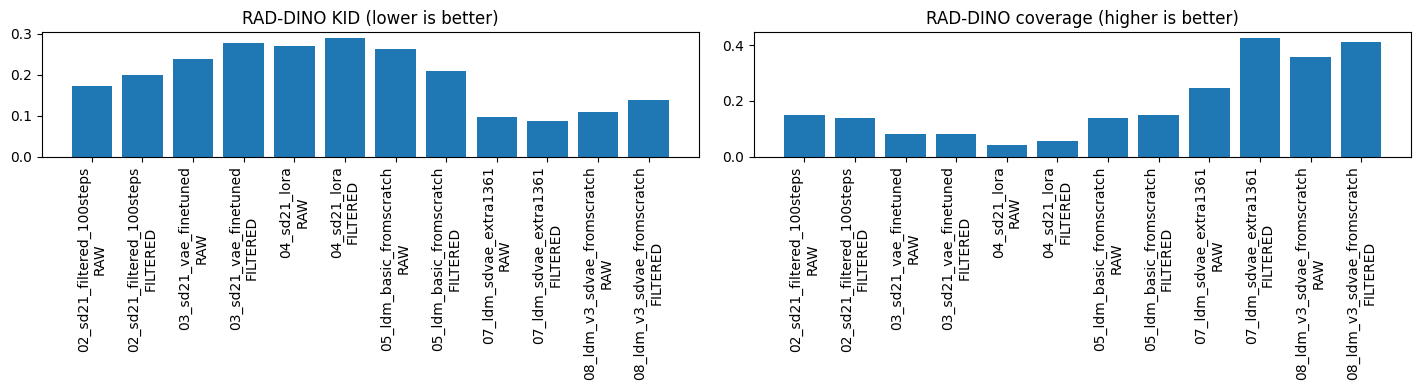

In [14]:
generator_summary = generator_ranking = None
if RUN_REAL_BENCHMARK:
    generator_summary = list(); audits_by_id = {row['generator_id']: row for row in candidate_audits}
    distributions = {(row['generator_id'], row['condition'], row['extractor']): row for row in distribution_summaries}
    diversities = {(row['generator_id'], row['condition']): row for row in diversity_rows}
    technical_by_condition = {(row['generator_id'], row['condition']): row for row in technical_rows}
    for technical in technical_rows:
        generator_id, condition = technical['generator_id'], technical['condition']; audit = audits_by_id[generator_id]
        raw_technical = technical_by_condition[(generator_id, 'RAW')]; filtered_technical = technical_by_condition[(generator_id, 'FILTERED')]
        rad = distributions.get((generator_id, condition, 'rad_dino')); inception = distributions.get((generator_id, condition, 'inception_v3')); diversity = diversities.get((generator_id, condition), dict())
        train_group = [row for row in train_memorization_rows if row['generator_id'] == generator_id and row['condition'] == condition]
        validation_group = [row for row in validation_similarity_rows if row['generator_id'] == generator_id and row['condition'] == condition]
        duplication_group = [row for row in synthetic_duplication_rows if row['generator_id'] == generator_id and row['condition'] == condition]
        train_rate = sum(row['memorization_flag'] for row in train_group) / len(train_group) if train_group else None
        duplicate_rate = sum(row['duplicate_flag'] for row in duplication_group) / len(duplication_group) if duplication_group else None
        entry = next(item for item in registry['generators'] if item['id'] == generator_id)
        summary = {'generator_id': generator_id, 'condition': condition, 'family': audit['scientific_family'], 'role': audit['candidate_role'],
                   'eligible_for_selection': audit['eligible_for_downstream_selection'], 'technical_validity': technical['eligible_for_distribution_metrics'],
                   'technical_validity_rate': technical['technical_validity_rate'], 'feature_extractable_rate': technical['feature_extractable_rate'], 'quality_validity_rate': technical['quality_validity_rate'],
                   'raw_feature_extractable_rate': raw_technical['feature_extractable_rate'], 'raw_quality_validity_rate': raw_technical['quality_validity_rate'], 'raw_near_black_rate': raw_technical['n_near_black'] / raw_technical['n_discovered'], 'raw_constant_range_rate': raw_technical['n_invalid_range'] / raw_technical['n_discovered'],
                   'filtered_feature_extractable_rate': filtered_technical['feature_extractable_rate'], 'filtered_quality_validity_rate': filtered_technical['quality_validity_rate'],
                   'eligible_for_official_ranking': condition == 'FILTERED' and technical['eligible_for_official_ranking'] and audit['eligible_for_official_family_ranking'],
                   'filter_acceptance_rate': audit.get('filter_acceptance_rate'), 'valid_positive_images': technical['n_unique_quality_valid_content'],
                   'provenance_manifest_valid': audit['provenance_manifest_valid'], 'lineage_complete': audit['lineage_complete'], 'filter_manifest_valid': audit['filter_manifest_valid'], 'filter_provenance_complete': audit.get('filter_provenance_complete'), 'n_corrupt': technical['n_corrupt'],
                   'training_corpus_manifest': audit.get('training_corpus_manifest'), 'training_corpus_manifest_valid': audit['training_corpus_manifest_valid'],
                   'raddino_kid': rad.get('kid_full_pool') if rad else None, 'raddino_kid_stability_low': rad.get('kid_stability_percentile_2_5') if rad else None,
                   'raddino_kid_stability_high': rad.get('kid_stability_percentile_97_5') if rad else None, 'raddino_kid_std': rad.get('kid_stability_standard_deviation') if rad else None,
                   'raddino_precision': rad.get('precision_balanced_point') if rad else None, 'raddino_recall': rad.get('recall_balanced_point') if rad else None,
                   'raddino_density': rad.get('density_balanced_point') if rad else None, 'raddino_coverage': rad.get('coverage_balanced_point') if rad else None,
                   'raddino_fid': rad.get('fid_full_pool') if rad else None, 'inception_kid': inception.get('kid_full_pool') if inception else None,
                   'inception_fid': inception.get('fid_full_pool') if inception else None, 'stability_interval_type': rad.get('stability_interval_type') if rad else None, 'ms_ssim_diversity': diversity.get('ms_ssim_diversity'),
                   'synthetic_duplicate_rate': duplicate_rate, 'synthetic_exact_duplicate_rate': diversity.get('synthetic_exact_duplicate_rate'),
                   'perceptual_hash_duplicate_rate': diversity.get('perceptual_hash_duplicate_rate'), 'train_memorization_rate': train_rate,
                   'validation_nearest_neighbour_distance': float(np.mean([row['embedding_distance'] for row in validation_group])) if validation_group else None,
                   **efficiency_from_manifest(ROOT, entry), 'metrics_complete': rad is not None and inception is not None, 'test_access': False}
        summary['technical_gates_passed'] = technical['eligible_for_distribution_metrics'] and not eligibility_failures(summary, protocol['eligibility_gates'])
        generator_summary.append(summary)
    write_csv_rows(OUTPUT_ROOT / 'generator_summary.csv', generator_summary)
    generator_ranking = list()
    filtered_rows = [row for row in generator_summary if row['condition'] == 'FILTERED' and row['eligible_for_official_ranking']]
    for family in ('finetuned', 'from_scratch'):
        generator_ranking.extend(rank_generator_family(filtered_rows, family, protocol['eligibility_gates']))
    write_csv_rows(OUTPUT_ROOT / 'generator_ranking.csv', generator_ranking)
    paired_rows = list()
    for family in ('finetuned', 'from_scratch'):
        top = [row for row in generator_ranking if row['family'] == family and row['eligible']][:2]
        if len(top) == 2:
            left = [row for row in distribution_repetitions if row['generator_id'] == top[0]['generator_id'] and row['condition'] == 'FILTERED' and row['extractor'] == 'rad_dino']
            right = [row for row in distribution_repetitions if row['generator_id'] == top[1]['generator_id'] and row['condition'] == 'FILTERED' and row['extractor'] == 'rad_dino']
            paired_rows.append({'family': family, **{key: value for key, value in paired_kid_differences(left, right, top[0]['generator_id'], top[1]['generator_id']).items() if key != 'paired_differences'}})
    if paired_rows: write_csv_rows(OUTPUT_ROOT / 'paired_generator_differences.csv', paired_rows)
    figure = plot_generator_summary(generator_summary); (OUTPUT_ROOT / 'figures').mkdir(parents=True, exist_ok=True); figure.savefig(OUTPUT_ROOT / 'figures/generator_summary.png', dpi=150)
generator_summary if generator_summary is not None else {'status': 'Deferred; no synthetic result rows were generated', 'output_root': str(OUTPUT_ROOT)}

## 15. Pareto analysis

In [15]:
ranking_view = generator_ranking if generator_ranking is not None else 'Deferred; ranking order is eligibility → RAD-DINO KID → coverage → precision → RAD-DINO FID → Inception KID → stability → generator_id.'
ranking_view

[{'generator_id': '02_sd21_filtered_100steps',
  'condition': 'FILTERED',
  'family': 'finetuned',
  'role': 'primary_candidate',
  'eligible_for_selection': True,
  'technical_validity': True,
  'technical_validity_rate': 1.0,
  'feature_extractable_rate': 1.0,
  'quality_validity_rate': 1.0,
  'raw_feature_extractable_rate': 1.0,
  'raw_quality_validity_rate': 1.0,
  'raw_near_black_rate': 0.0,
  'raw_constant_range_rate': 0.0,
  'filtered_feature_extractable_rate': 1.0,
  'filtered_quality_validity_rate': 1.0,
  'eligible_for_official_ranking': True,
  'filter_acceptance_rate': 0.5,
  'valid_positive_images': 1361,
  'provenance_manifest_valid': True,
  'lineage_complete': True,
  'filter_manifest_valid': True,
  'filter_provenance_complete': True,
  'n_corrupt': 0,
  'training_corpus_manifest': 'results/publication_v2/generator_provenance/runtime/shared/rsna_train_real_plus_positive_augmentation.csv',
  'training_corpus_manifest_valid': True,
  'raddino_kid': 0.1990891096955254,
  

## 16. Visual panels

In [16]:
panel_outputs = None
if RUN_REAL_BENCHMARK:
    panel_outputs = list(); panel_root = OUTPUT_ROOT / 'diagnostic_panels'
    for audit in candidate_audits:
        for representation in REPRESENTATIONS:
            key = (audit['generator_id'], representation)
            if key not in benchmark_keys:
                continue
            condition = representation.upper(); synthetic_map = dict(zip(candidate_ids[key], candidate_paths[key]))
            train_panel = [{**row, 'source_id': row['nearest_train_id']} for row in train_memorization_rows if row['generator_id'] == audit['generator_id'] and row['condition'] == condition]
            validation_panel = [{**row, 'source_id': row['nearest_validation_id']} for row in validation_similarity_rows if row['generator_id'] == audit['generator_id'] and row['condition'] == condition]
            synthetic_panel = [{**row, 'source_id': row['nearest_synthetic_id']} for row in synthetic_duplication_rows if row['generator_id'] == audit['generator_id'] and row['condition'] == condition]
            for name, rows, references in (('train', train_panel, train_path_map), ('validation', validation_panel, validation_path_map), ('synthetic', synthetic_panel, synthetic_map)):
                output = panel_root / f"{audit['generator_id']}_{representation}_{name}.png"
                panel_outputs.append(str(render_similarity_panel(rows, synthetic_map, references, output, f"{audit['generator_id']} {condition}: synthetic | nearest {name}")))
    execution_config.update({'status': 'complete', 'completed_at_utc': dt.datetime.now(dt.timezone.utc).isoformat(), 'cache_hits': sum(row['cache_event'] == 'hit' for row in cache_events), 'cache_misses': sum(row['cache_event'] == 'miss' for row in cache_events), 'cache_events': cache_events, 'feature_extraction_failures': feature_extraction_failures})
    atomic_json(run_root / 'execution_config.json', execution_config)
panel_outputs if panel_outputs is not None else {'status': 'Deferred', 'policy': 'deterministic closest / median / farthest for train, validation and synthetic'}

['/mnt/MammoDiffusion/MammoDiffusion/results/publication_v2/generator_benchmark/diagnostic_panels/02_sd21_filtered_100steps_raw_train.png',
 '/mnt/MammoDiffusion/MammoDiffusion/results/publication_v2/generator_benchmark/diagnostic_panels/02_sd21_filtered_100steps_raw_validation.png',
 '/mnt/MammoDiffusion/MammoDiffusion/results/publication_v2/generator_benchmark/diagnostic_panels/02_sd21_filtered_100steps_raw_synthetic.png',
 '/mnt/MammoDiffusion/MammoDiffusion/results/publication_v2/generator_benchmark/diagnostic_panels/02_sd21_filtered_100steps_filtered_train.png',
 '/mnt/MammoDiffusion/MammoDiffusion/results/publication_v2/generator_benchmark/diagnostic_panels/02_sd21_filtered_100steps_filtered_validation.png',
 '/mnt/MammoDiffusion/MammoDiffusion/results/publication_v2/generator_benchmark/diagnostic_panels/02_sd21_filtered_100steps_filtered_synthetic.png',
 '/mnt/MammoDiffusion/MammoDiffusion/results/publication_v2/generator_benchmark/diagnostic_panels/03_sd21_vae_finetuned_raw_tra